In [4]:
import numpy as np
from numpy import mean
import matplotlib.pyplot as plt
import pandas as pd
import os
import random
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold, f_classif
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.model_selection import train_test_split
from skrebate import ReliefF
from scipy.stats import kstest, f_oneway, kruskal

datapath = 'FacialTracking_Actors_01-24'
nlandmarks = 68

def preprareData(files):

    actors = np.zeros((len(files)), dtype=np.uint8)
    emotions = np.zeros((len(files)), dtype=np.uint8)
    frames = np.zeros((len(files)), dtype=np.uint16)

    all_data = []

    for i in range(len(files)):
        filename = files[i]
        
        dataset = pd.read_csv(datapath + '/' + filename, sep=',')
        all_data.append(np.array(dataset.loc[:, 'x_0':'y_'+str(nlandmarks-1)]))
        
        parts = filename[:-4].split('-')
        actors[i] = int(parts[-1])
        emotions[i] = int(parts[2])     
        frames[i] = len(dataset.index)

    data = np.empty(shape=(len(files), nlandmarks*2, int(np.max(frames))), dtype=np.float32)
    data[:] = np.nan

    for i in range(len(files)):
        data[i, :, :int(frames[i])] = all_data[i].T

    return (data, actors, emotions, frames)

files = os.listdir(datapath)

data, actors, emotions, frames = preprareData(files)

np.save('data.npy', data)
np.save('actors.npy', actors)
np.save('emotions.npy', emotions)
np.save('frames.npy', frames)

In [5]:
def reshapeData(data3d, emotions, actors, frames):

    data2d = np.empty(shape=(np.sum(frames), data.shape[1]), dtype=np.float32)
    emotions_by_frame = np.empty(shape=(np.sum(frames)), dtype=np.uint8)
    actor_by_frame = np.empty(shape=(np.sum(frames)), dtype=np.uint8)

    k = 0
    for v in range(data3d.shape[0]):
        data2d[k:k+frames[v], :] = data3d[v, :, :frames[v]].T

        emotions_by_frame[k:k+frames[v]] = emotions[v]
        actor_by_frame[k:k+frames[v]] = actors[v]

        k += frames[v]

    return (data2d, emotions_by_frame, actor_by_frame)
#
def getData(actor=None, emotion=None, type='2d'):

    data = np.load('data.npy')
    actors = np.load('actors.npy')
    emotions = np.load('emotions.npy')
    frames = np.load('frames.npy')

    if type=='2d':
        data, emotions, actors = reshapeData(data, emotions, actors, frames)

        if actor is not None:
            data = data[actors == actor,:]
            emotions = emotions[actors == actor]
            actors = actors[actors == actor]
        
        if emotion is not None:
            data = data[emotions == emotion,:]
            actors = actors[emotions == emotion]
            emotions = emotions[emotions == emotion]
            
    
    elif type=='3d':
        if actor is not None:
            data = data[actors == actor,:,:]
            emotions = emotions[actors == actor]
            actors = actors[actors == actor]
        
        if emotion is not None:
            data = data[emotions == emotion,:,:]
            actors = actors[emotions == emotion]    
            emotions = emotions[emotions == emotion]
            
    return (data, emotions, actors)

In [6]:
#Shape

print("Shape:")

data3d, emotions3d, actors3d = getData(type='3d')
print(data3d.shape, emotions3d.shape, actors3d.shape, np.isnan(data3d).any())

data2d, emotions2d,actors2d = getData(type='2d')
print(data2d.shape, emotions2d.shape, actors2d.shape, np.isnan(data2d).any())

data3da1, emotions3da1, actors3da1 = getData(actor=1, type='3d')
print(data3da1.shape, emotions3da1.shape, actors3da1.shape, np.isnan(data3da1).any())

data2da1, emotions2da1, actors2da1 = getData(actor=1, type='2d')
print(data2da1.shape, emotions2da1.shape, actors2da1.shape, np.isnan(data2da1).any())

data3de1, emotions3de1, actors3de1 = getData(emotion=1, type='3d')
print(data3de1.shape, emotions3de1.shape, actors3de1.shape, np.isnan(data3de1).any())

data2de1, emotions2de1, actors2de1 = getData(emotion=1, type='2d')
print(data2de1.shape, emotions2de1.shape, actors2de1.shape, np.isnan(data2de1).any())

data3da1e1, emotions3da1e1, actors3da1e1 = getData(actor=1, emotion=1, type='3d')
print(data3da1e1.shape, emotions3da1e1.shape, actors3da1e1.shape, np.isnan(data3da1e1).any())

data2da1e1, emotions2da1e1, actors2da1e1 = getData(actor=1, emotion=1, type='2d')
print(data2da1e1.shape, emotions2da1e1.shape, actors2da1e1.shape, np.isnan(data2da1e1).any())

Shape:
(2452, 136, 191) (2452,) (2452,) True
(299854, 136) (299854,) (299854,) False
(104, 136, 191) (104,) (104,) True
(12668, 136) (12668,) (12668,) False
(188, 136, 191) (188,) (188,) True
(22458, 136) (22458,) (22458,) False
(8, 136, 191) (8,) (8,) True
(888, 136) (888,) (888,) False


In [7]:
x_coordinates = data2d[:, :68]  # Columns x_0 to x_67
y_coordinates = data2d[:, 68:]  # Columns y_0 to y_67

x_coordinates_first_frame = x_coordinates[0]
y_coordinates_first_frame = y_coordinates[0]

x_coordinate_landmark_0 = x_coordinates_first_frame[0]
y_coordinate_landmark_0 = y_coordinates_first_frame[0]

In [8]:
#Gráfico Facial
def visualize_facial_landmarks(frame_landmarks, title=None):
    plt.figure()
    plt.axis('equal')
    plt.gca().invert_yaxis() 
    plt.scatter(frame_landmarks[:, 0], frame_landmarks[:, 1], c='black', marker='o')

    if title:
        plt.title(title)

    plt.show()

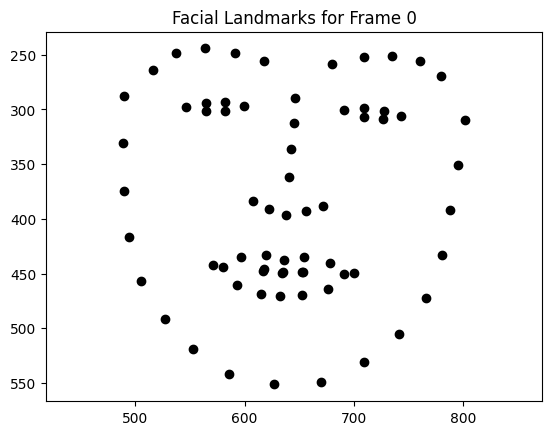

In [9]:
frame_landmarks = np.column_stack((x_coordinates_first_frame, y_coordinates_first_frame))

visualize_facial_landmarks(frame_landmarks, title="Facial Landmarks for Frame 0")

In [10]:
#Gráfico Multipla Faces
def visualize_facial_landmarks_(frame_landmarks_list, title=None):
    plt.figure()
    plt.axis('equal')  # Ensure aspect ratio is maintained
    plt.gca().invert_yaxis()  # Invert the y-axis to match typical facial landmark plotting

    for frame_landmarks in frame_landmarks_list:
        plt.scatter(frame_landmarks[:, 0], frame_landmarks[:, 1], c='black', marker='o')

    if title:
        plt.title(title)

    plt.show()

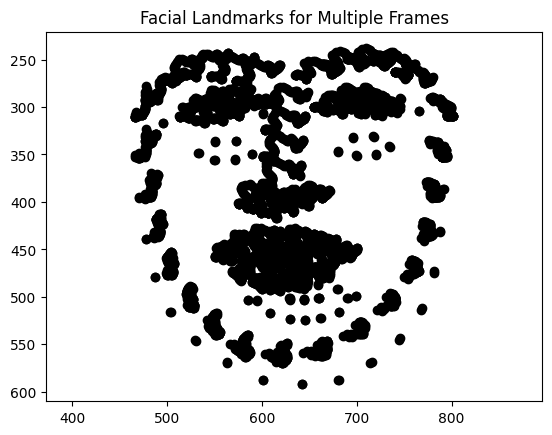

In [11]:
num_frames4 = data2d.shape[0]
frame_landmarks_list = []

for i in range(100):
    x_coordinates_frame = x_coordinates[i]
    y_coordinates_frame = y_coordinates[i]
    
    frame_landmarks = np.column_stack((x_coordinates_frame, y_coordinates_frame))
    
    frame_landmarks_list.append(frame_landmarks)


visualize_facial_landmarks_(frame_landmarks_list, title="Facial Landmarks for Multiple Frames") # 100 primeiros valores da data2d

In [12]:
#Normalização
def normalizacao(data):
    x27, y27 = data[:, 27], data[:, 94]

    xref = x27
    yref = y27

    xmax = 1280
    ymax = 720

    norm_data = np.zeros_like(data)

    norm_data[:, :68] = (data[:, :68] - xref[:, np.newaxis]) / xmax #np.newaxis  para aumentar a dimensão 

    norm_data[:, 68:] = (data[:, 68:] - yref[:, np.newaxis]) / ymax #np.newaxis  para aumentar a dimensão
    
    return norm_data

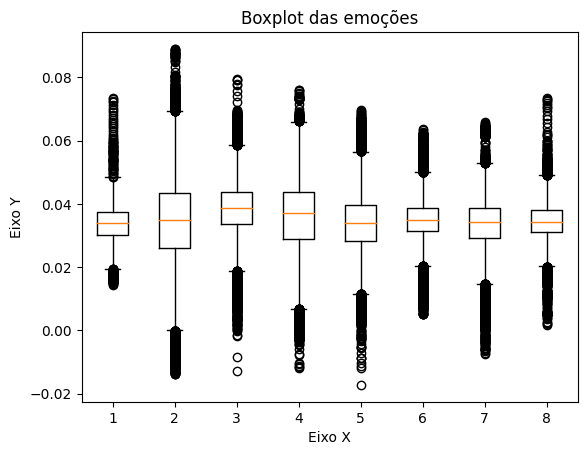

In [13]:
#Normalização + Boxplot das emoções
data1, emotions1, actors1 = getData(emotion=1, type='2d')
data2, emotions2, actors2 = getData(emotion=2, type='2d')
data3, emotions3, actors3 = getData(emotion=3, type='2d')
data4, emotions4, actors4 = getData(emotion=4, type='2d')
data5, emotions5, actors5 = getData(emotion=5, type='2d')
data6, emotions6, actors6 = getData(emotion=6, type='2d')
data7, emotions7, actors7 = getData(emotion=7, type='2d')
data8, emotions8, actors8 = getData(emotion=8, type='2d')

data2d = normalizacao(data2d)

data1 = normalizacao(data1)
data2 = normalizacao(data2)
data3 = normalizacao(data3)
data4 = normalizacao(data4)
data5 = normalizacao(data5)
data6 = normalizacao(data6)
data7 = normalizacao(data7)
data8 = normalizacao(data8)

alldatabox = [data1[:,53],data2[:,53],data3[:,53],data4[:,53],data5[:,53],data6[:,53],data7[:,53],data8[:,53]]

plt.boxplot(alldatabox)

plt.title('Boxplot das emoções')
plt.xlabel('Eixo X')
plt.ylabel('Eixo Y')

plt.show()

In [14]:
#Densidade de outliers - Outliers k = 3.5 - por emoção
def densidade_outliers(ldata):
    outlier_stats = {1: "Neutral",2: "Calm",3: "Happy",4: "Sad",5: "Angry",6: "Fearful",7: "Disgust",8: "Surprised"}
    aux = 1

    for data in ldata:
        emotion_outlier_info = []
        for j in range(len(data[0])):
            datav = data[:,j]

            Q1 = np.percentile(datav, 25)
            Q3 = np.percentile(datav, 75)

            IQR = Q3 - Q1

            outliers = ((datav < (Q1 - 3.5 * IQR)) | (datav > (Q3 + 3.5 * IQR)))

            no = np.sum(outliers) # número de outliers
            nr = len(data) # número de frames

            densidade = (no / nr) * 100
            emotion_outlier_info.append(densidade)
              
        outlier_stats[aux] = {'mean_density': np.mean(emotion_outlier_info),'std_density': np.std(emotion_outlier_info)}
        aux +=1
    
    return outlier_stats

alldata = [data1,data2,data3,data4,data5,data6,data7,data8]

outlier_stats = densidade_outliers(alldata)

print(outlier_stats)

{1: {'mean_density': 0.018072951863085603, 'std_density': 0.03203093231763495}, 2: {'mean_density': 0.0023025291574466466, 'std_density': 0.010143438288619164}, 3: {'mean_density': 0.03926382336895479, 'std_density': 0.05564679348565839}, 4: {'mean_density': 0.0057893547126883, 'std_density': 0.015235810681257561}, 5: {'mean_density': 0.04982344694536976, 'std_density': 0.14256246540523496}, 6: {'mean_density': 0.032645577788709225, 'std_density': 0.05617218386108138}, 7: {'mean_density': 0.05462519313907574, 'std_density': 0.12486422261975103}, 8: {'mean_density': 0.08655273250944144, 'std_density': 0.21296382797189586}}


In [15]:
#Z-score
def z_score(outlier_stats,alldata):
    z_scores_stats = {1: "Neutral",2: "Calm",3: "Happy",4: "Sad",5: "Angry",6: "Fearful",7: "Disgust",8: "Surprised"}
    for i in range(len(alldata)):
        aux = outlier_stats[i+1]

        media = aux['mean_density']

        desvio_padrao = aux['std_density']

        z_scoreaux = (alldata[i] - media) / desvio_padrao
        z_scores_stats[i+1] = {'z-score' : z_scoreaux}

    return z_scores_stats

z_scores_stats = z_score(outlier_stats,alldatabox)

print(z_scores_stats)

{1: {'z-score': array([0.19918756, 0.19430918, 0.18699232, ..., 0.84309703, 0.84553546,
       0.84553695], dtype=float32)}, 2: {'z-score': array([4.278687 , 4.3171973, 4.3403025, ..., 6.5584884, 6.4814634,
       6.396744 ], dtype=float32)}, 3: {'z-score': array([-0.21701756, -0.22263284, -0.22824894, ...,  0.25190017,
        0.2547074 ,  0.25611183], dtype=float32)}, 4: {'z-score': array([2.5735831, 2.7222886, 2.81459  , ..., 4.0554957, 4.0862646,
       4.086261 ], dtype=float32)}, 5: {'z-score': array([-0.02725793, -0.0272576 , -0.02561399, ..., -0.13959904,
       -0.14781912, -0.15110736], dtype=float32)}, 6: {'z-score': array([0.12536298, 0.11423662, 0.11284617, ..., 0.17682317, 0.17404142,
       0.17543273], dtype=float32)}, 7: {'z-score': array([-0.10962085, -0.11274888, -0.10962085, ..., -0.09835869,
       -0.09960975, -0.1002353 ], dtype=float32)}, 8: {'z-score': array([-0.19731747, -0.19951846, -0.20061916, ..., -0.1727387 ,
       -0.16907024, -0.16173354], dtype=float3

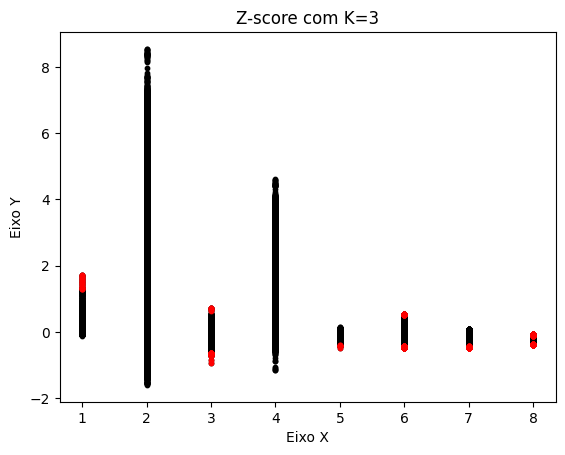

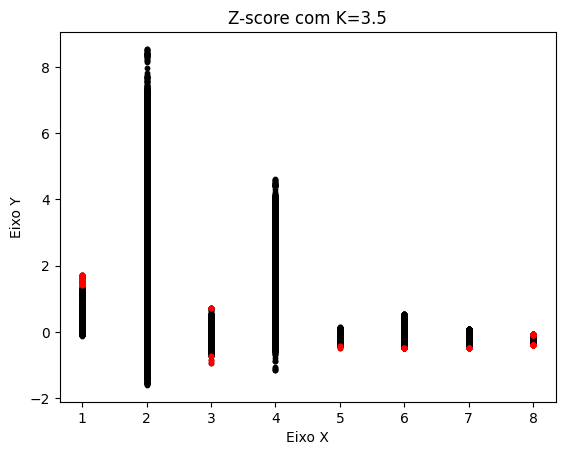

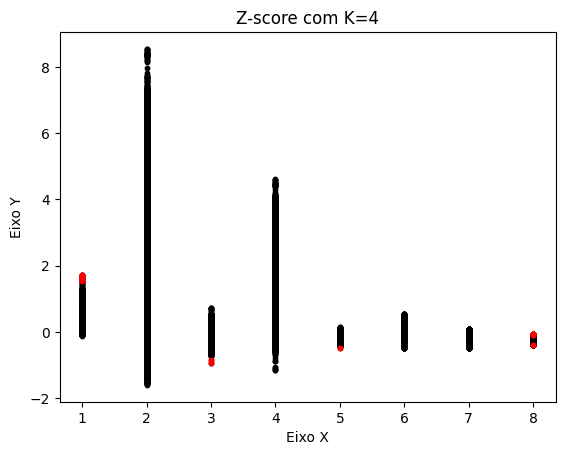

In [16]:
#Z-score - C/ Outliers - K =3,3.5,4
def z_score_outliers(stats,k):
    for j in range(len(stats)):    
        aux = stats[j+1]
        aux1 = aux['z-score']

        Q1 = np.percentile(aux1, 25)
        Q3 = np.percentile(aux1, 75)

        IQR = Q3 - Q1
        outliers = ((aux1 < (Q1 - k * IQR)) | (aux1 > (Q3 + k * IQR)))

        plt.scatter(np.full_like(aux1, j+1), aux1, s=10,c ='black')
        plt.scatter(np.full_like(aux1, j+1)[outliers], aux1[outliers], s=10,c ='red')

        plt.xlabel('Eixo X')
        plt.ylabel('Eixo Y')
        
    plt.title('Z-score com K='+str(k))
    plt.show()

z_score_outliers(z_scores_stats,3)
z_score_outliers(z_scores_stats,3.5)
z_score_outliers(z_scores_stats,4)

No BoxPlot executado anteriormente é uma ferramenta eficaz para visualizar a distribuição do nosso conjunto de dados. Por meio dele, conseguimos uma representação gráfica de diversas estatísticas , incluindo a mediana, os quartis e outliers.Vemos que na emoção 1 há valores mais distantes, como na 5 e 8. Na 2 apesar de serem bastante diversos os dados, não há propriamente algum valor soante como outlier; Na 6 e 7 acontece os mesmo mas os valores não são tão dispersos. Na 4 há outliers no eixo positivo e negativo do y. 
Ao realizar o Z-score observamos que as estatísticas do boxplot estavam certas. A emoção 2 e 4 com uma vasta gama de dados mas sem outliers. E as restantes o contrário, havendo outliers alguns mais visiveis que outros, como no caso da emção 8 que em qualquer k tem sempre outliers.

In [17]:
#KMeans
def k_means(data, k):
    kmeans = KMeans(k).fit(data)
    labels, centroides = kmeans.labels_, kmeans.cluster_centers_

    plt.scatter(data[:,0],data[:,1],c = labels, s=20)
    plt.scatter(centroides[:, 0], centroides[:, 1], c='black', marker='x', s=20)


    plt.title('K-means com k='+str(k))
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True)
    plt.show()

    return labels,centroides

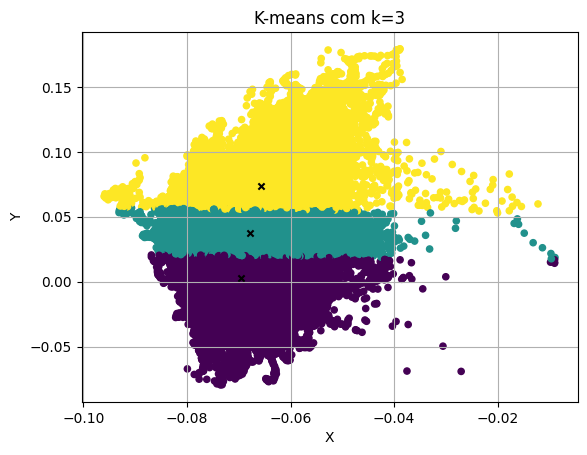

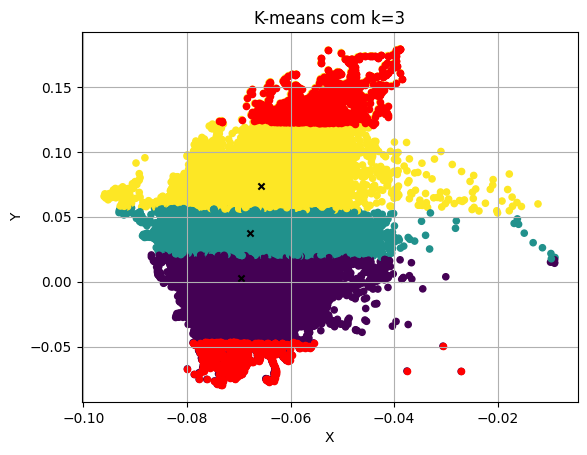

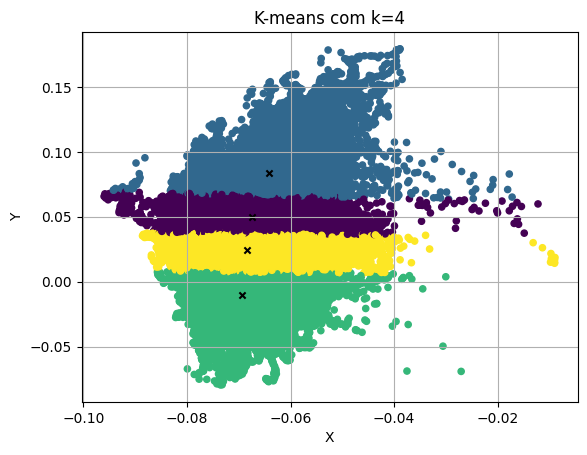

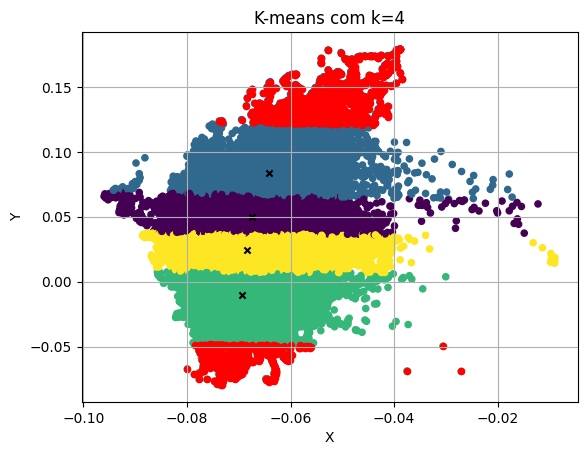

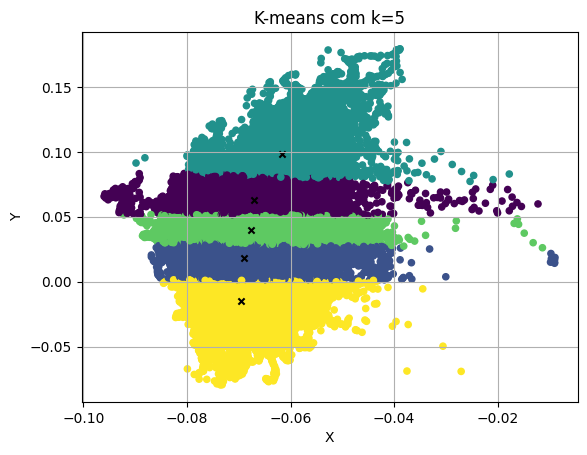

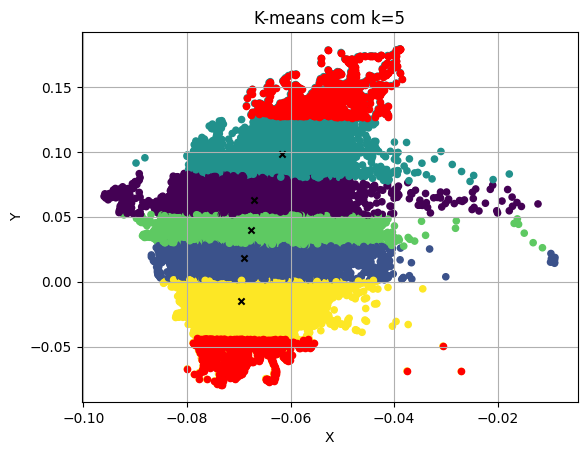

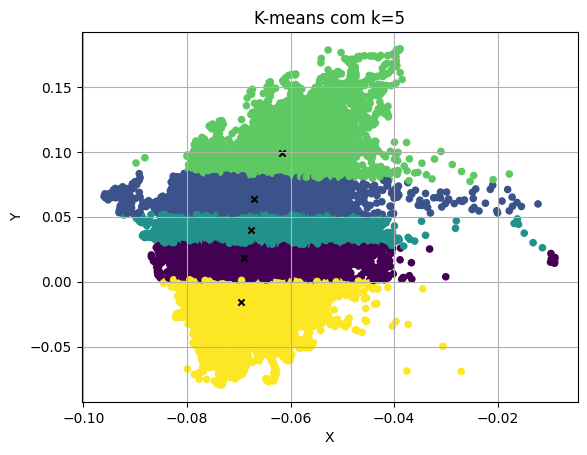

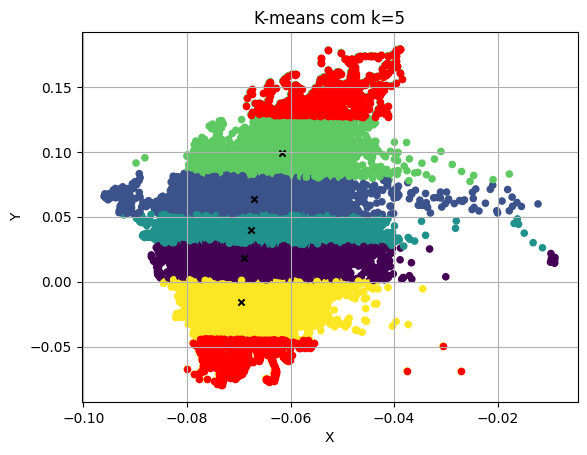

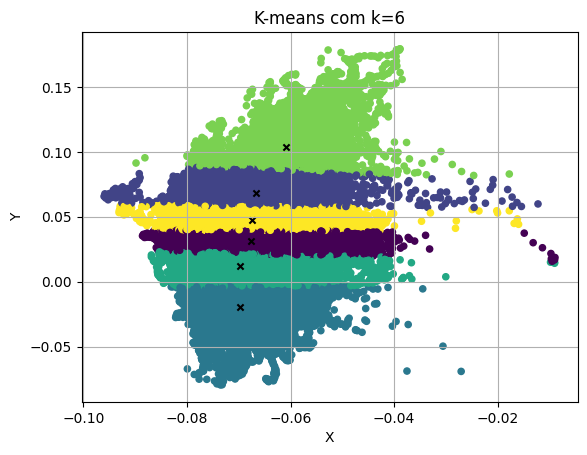

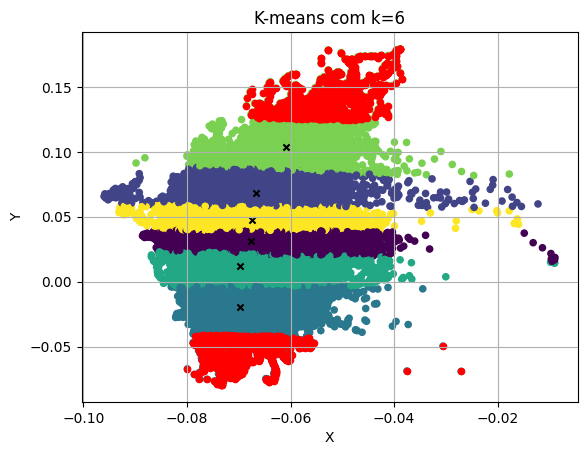

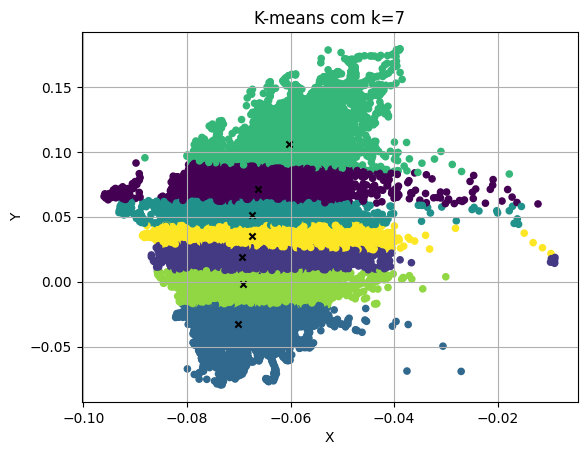

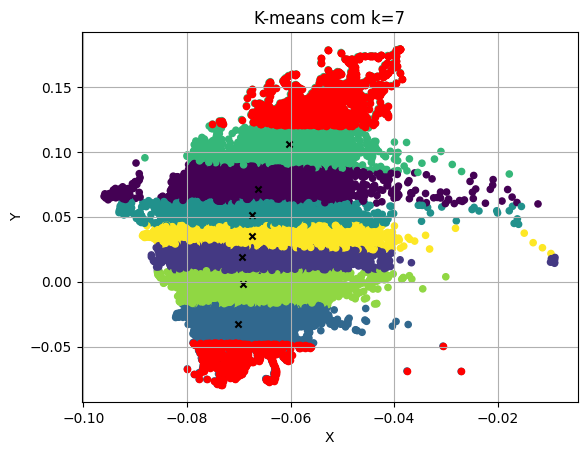

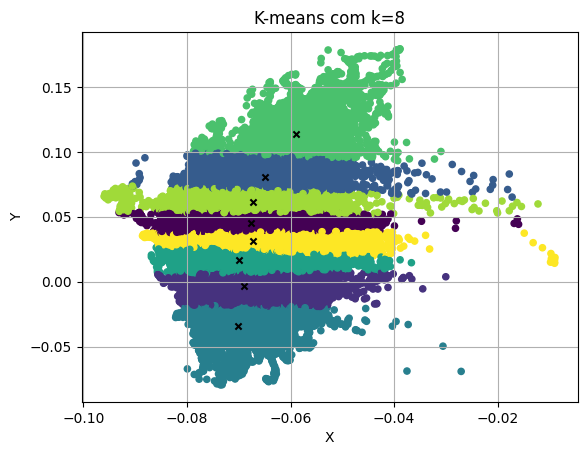

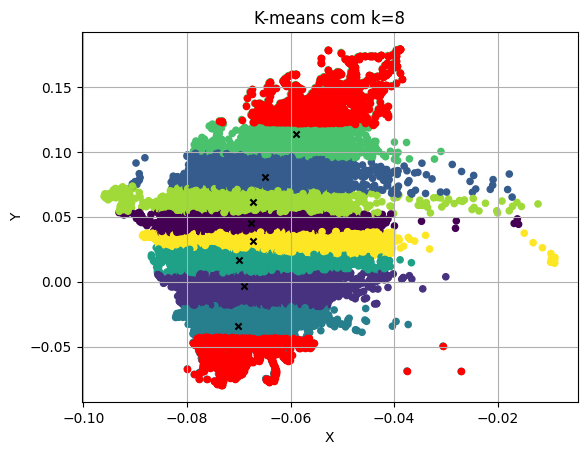

In [18]:
#KMeans - Outliers
def outliers_k_means(data,lk):
    for k in lk:
        labels,centroides = k_means(data,k)
        
        distancia = np.linalg.norm(data[:, np.newaxis] - centroides, axis=2)

        media_distancia = np.median(distancia)
        desvio_padrao_distancia = np.std(distancia)

        outlier_limite = media_distancia + 4 * desvio_padrao_distancia

        outliers = np.where(distancia > outlier_limite)[0]

        plt.scatter(data[:,0],data[:,1],c = labels, s=20)
        plt.scatter(data[outliers, 0], data[outliers, 1], c='red', s=20)
        plt.scatter(centroides[:, 0], centroides[:, 1], c='black', marker='x', s=20)


        plt.title('K-means com k='+str(k))
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.grid(True)
        plt.show()

landmark = 37
outliers_k_means(data2d[:,[landmark, 68 + landmark]],[3,4,5,5,6,7,8])

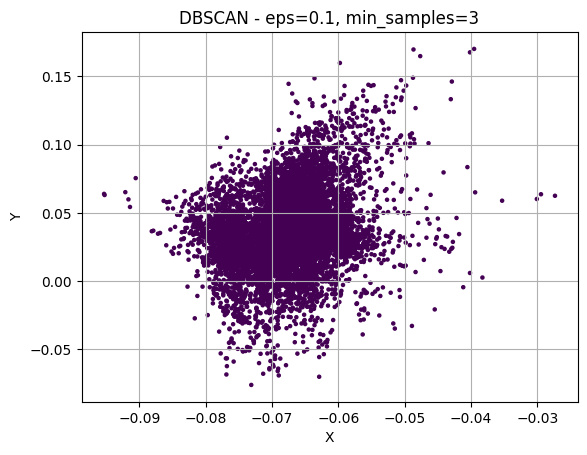

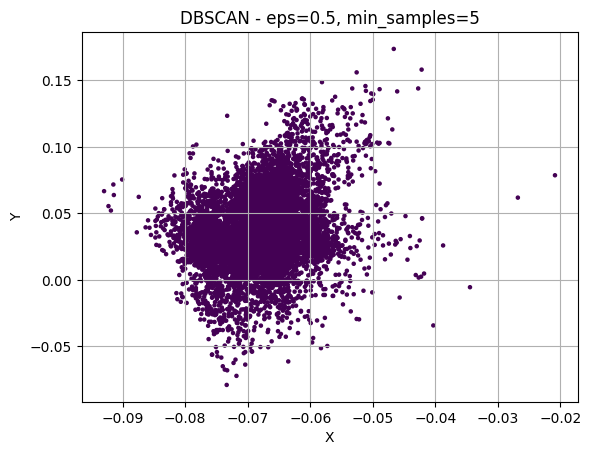

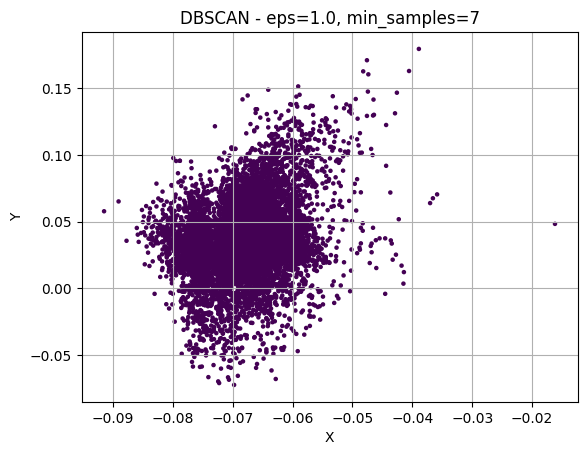

In [19]:
#DBSCAN
def outliers_dbscan(data, eps, min_samples):
    tamanho = 10000  # Tamanho variável
    limites = np.random.choice(len(data), size=tamanho, replace=False)
    dataAux = data[limites]

    dbscan = DBSCAN(eps=eps, min_samples=min_samples, algorithm='auto', metric='euclidean')
    labels = dbscan.fit_predict(dataAux)

    outliers = np.where(labels == -1)[0]

    plt.scatter(dataAux[:, 0], dataAux[:, 1], c=labels, s=5)
    plt.scatter(dataAux[outliers, 0], dataAux[outliers, 1], c='red', s=5)

    plt.title(f'DBSCAN - eps={eps}, min_samples={min_samples}')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True)
    plt.show()

landmark = 37
outliers_dbscan(data2d[:, [landmark, 68 + landmark]], eps=0.1, min_samples=3)
outliers_dbscan(data2d[:, [landmark, 68 + landmark]], eps=0.5, min_samples=5)
outliers_dbscan(data2d[:, [landmark, 68 + landmark]], eps=1.0, min_samples=7)

In [20]:
#Extrair Features posição média da coordenada x e y de 10 landmarks
numeros_aleatorios = random.sample(range(68), 10)
numeros_aleatorios = sorted(numeros_aleatorios)

def posicao_media(dataset, landmarks):
    nlandmarks = 68
    media=[]

    for j in landmarks:
        x_ind = j
        y_ind = j + nlandmarks

        x_media = np.nanmean(dataset[:, x_ind], axis=1)
        y_media = np.nanmean(dataset[:, y_ind], axis=1)

        media.append(x_media)
        media.append(y_media)
    
    return media

def dataframe_medias(dataset, landmarks):
    media = posicao_media(dataset,landmarks)

    df = pd.DataFrame(np.array(media).T)
    df.columns =  [f'x_mean_{i}' for i in landmarks] + [f'y_mean_{i}' for i in landmarks]
    
    return df


df_media_landmarks = dataframe_medias(data3d,numeros_aleatorios)
df_media_landmarks.head(5)

,x_mean_15,x_mean_21,x_mean_22,x_mean_25,x_mean_26,x_mean_39,x_mean_42,x_mean_46,x_mean_51,x_mean_55,y_mean_15,y_mean_21,y_mean_22,y_mean_25,y_mean_26,y_mean_39,y_mean_42,y_mean_46,y_mean_51,y_mean_55
0,787.683655,344.901001,596.393860,263.701019,659.689758,261.963257,740.738770,253.016342,761.264282,266.878540,585.872437,298.522430,674.710205,297.809204,712.729614,302.590820,622.628540,443.625519,666.061279,471.723450
1,789.745850,385.900940,597.442261,302.270630,666.654114,300.211945,743.820190,287.253235,762.766052,300.149536,587.018372,346.177063,677.947693,343.589905,717.794434,346.715607,641.126587,487.207367,680.035767,520.120178
2,821.718445,373.314545,630.262146,292.758240,689.424316,295.291260,781.965027,293.465027,799.791260,311.918457,613.039795,333.063080,701.782471,337.110657,740.663086,344.965027,652.225281,483.883484,693.150513,521.696167
3,781.035339,347.902039,609.078796,242.596985,673.572693,248.182831,750.242371,249.700012,765.487854,267.806061,594.242371,302.011108,680.255554,308.788910,721.241455,318.412109,628.867676,438.568695,667.948547,480.264648
4,835.708313,371.737946,618.141724,246.688889,684.894470,249.296295,781.881531,251.947205,801.500000,272.484253,602.026855,306.987946,702.337952,309.410187,747.755554,317.661102,650.103760,471.894470,698.596375,515.161987


In [21]:
#Extrair Features métricas estatisticas
def metricas_estatisticas(data,landmarks):
    nlandmarks = 68
    estatisticas = []

    for data_num in range(data.shape[0]):  
        anguloL = []
        areaL = []
        distanciaL = []
        
        for frame in range(data.shape[2]):
            x = data[data_num, landmarks,frame]
            y = data[data_num, [i + nlandmarks for i in landmarks],frame]

            an = angulo(x[:-1], y[:-1], x[1:], y[1:])
            anguloL.append(an)
            ar = area(x[:-2], y[:-2], x[1:-1], y[1:-1], x[2:], y[2:])
            areaL.append(ar)
            di = distancia(x[:-1], y[:-1], x[1:], y[1:])
            distanciaL.append(di)

        data_statistics = [np.nanmean(anguloL), np.nanstd(anguloL),np.nanmean(areaL), np.nanstd(areaL),np.nanmean(distanciaL), np.nanstd(distanciaL)]

        estatisticas.append(data_statistics)

    return estatisticas


def angulo(x1, y1, x2, y2):
    return np.degrees(np.arctan2(y2 - y1, x2 - x1))

def area(x1, y1, x2, y2, x3, y3):
    return 0.5 * np.abs((x1*(y2-y3) + x2*(y3-y1) + x3*(y1-y2)))

def distancia(x1, y1, x2, y2):
    return np.linalg.norm(np.array([x2 - x1, y2 - y1]), axis=0)


def dataframe_metricas(data, landmarks):
    estatisticas = metricas_estatisticas(data,landmarks)

    df = pd.DataFrame(estatisticas)
    df.columns = ['angle_mean', 'angle_std','area_mean', 'area_std','distance_mean', 'distance_std']

    return df

df_metricas_estatisticas = dataframe_metricas(data3d, numeros_aleatorios)
df_metricas_estatisticas.head(5)


,angle_mean,angle_std,area_mean,area_std,distance_mean,distance_std
0,22.330868,85.926476,1748.201660,1382.458984,100.403175,63.283176
1,21.419968,84.760544,1827.764038,1322.663940,100.457985,63.072380
2,26.914846,86.530197,1780.317749,1381.568726,102.497391,63.638062
3,29.753063,84.154457,1885.099854,1370.860596,97.667076,59.233219
4,27.298077,84.169701,2425.118164,1886.158691,115.539154,73.271194


In [22]:
#Extrair Features calcular estatisticas
def calculo_estatisticas(data,landmarks):
    nlandmarks = 68
    estatisticas = []

    for i in range(data.shape[0]):  
        xlf = []
        ylf = []
        
        for j in range(1, data.shape[2]):
            for l in landmarks:
                x_current = data[i, l, j]
                y_current = data[i, l+nlandmarks, j]
                x_prev = data[i, l, j-1]
                y_prev = data[i, l+nlandmarks, j-1]

                xaux = x_current - x_prev
                yaux = y_current - y_prev
                xlf.append(xaux)
                ylf.append(yaux)

        data_estatisticas = [np.nanmean(xlf), np.nanstd(xlf),np.nanmean(ylf),np.nanstd(ylf)]

        estatisticas.append(data_estatisticas)
    
    return estatisticas

def dataframe_estatisticas(data,landmarks):
    estatisticas = calculo_estatisticas(data,landmarks)

    df = pd.DataFrame(estatisticas)
    df.columns = ['x_diff_mean', 'x_diff_std','y_diff_mean', 'y_diff_std']

    return df

df_calculo_estatisticas = dataframe_estatisticas(data3d,numeros_aleatorios)
df_calculo_estatisticas.head(5)

,x_diff_mean,x_diff_std,y_diff_mean,y_diff_std
0,-0.349485,0.783203,0.015979,1.075108
1,-0.144259,0.613886,0.126296,1.162896
2,-0.036961,0.395956,-0.077745,1.053856
3,-0.028367,0.879849,-0.076939,1.370781
4,0.025047,0.290615,-0.020187,0.735727


In [23]:
#Significância estatisticas da diferença dos seus valores médios
#Foi comparado com o teste de Anderson-Darling mas era sempre usado o teste Kruskal-Wallis e nunca o ANOVA
features_finais = pd.concat([df_media_landmarks, df_metricas_estatisticas, df_calculo_estatisticas], axis=1)

alpha = 0.05
results_df = pd.DataFrame()

for i in features_finais.columns:
    feature = features_finais[i].ravel()

    print("-"+i+":")

    has_nan = np.isnan(feature).any()

    if has_nan:
        print("Há valores NaN no array em "+i+".")
    else:
        print("Não há valores NaN no array em "+i+".")

    feature_normalizadas = (feature - np.mean(feature)) / np.std(feature)

    ks_stat, ks_valor = kstest(feature_normalizadas, 'norm')

    if ks_valor < alpha:
        print("A distribuição de "+i+" não está de acordo com o KS test.")
        h_stat, p_valor = kruskal(feature_normalizadas, emotions)
        teste_usado = "Kruskal-Wallis"
    else:
        print("A distribuição de "+i+" está de acordo com o KS test.")
        f_stat, p_valor = f_oneway(feature_normalizadas, emotions)
        teste_usado = "ANOVA"

    if p_valor < alpha:
        print("Usando o teste "+teste_usado+" para "+i+" há provas para rejeitar.")
    else:
        print("Usando o teste "+teste_usado+" para "+i+" não há provas para rejeitar.")

    results_df = pd.concat([results_df, pd.DataFrame({'p_value': [p_valor], 'Test Used': [teste_usado]})], ignore_index=True)

-x_mean_15:
Não há valores NaN no array em x_mean_15.
A distribuição de x_mean_15 não está de acordo com o KS test.
Usando o teste Kruskal-Wallis para x_mean_15 há provas para rejeitar.
-x_mean_21:
Não há valores NaN no array em x_mean_21.
A distribuição de x_mean_21 está de acordo com o KS test.
Usando o teste ANOVA para x_mean_21 há provas para rejeitar.
-x_mean_22:
Não há valores NaN no array em x_mean_22.
A distribuição de x_mean_22 não está de acordo com o KS test.
Usando o teste Kruskal-Wallis para x_mean_22 há provas para rejeitar.
-x_mean_25:
Não há valores NaN no array em x_mean_25.
A distribuição de x_mean_25 está de acordo com o KS test.
Usando o teste ANOVA para x_mean_25 há provas para rejeitar.
-x_mean_26:
Não há valores NaN no array em x_mean_26.
A distribuição de x_mean_26 não está de acordo com o KS test.
Usando o teste Kruskal-Wallis para x_mean_26 há provas para rejeitar.
-x_mean_39:
Não há valores NaN no array em x_mean_39.
A distribuição de x_mean_39 não está de ac

Concluimos que em algumas features há distribuições normais.

In [24]:
#PCA
pca = PCA(n_components=10) 

pca.fit(features_finais)

features_pca = pca.transform(features_finais)

print("Variância explicada pelos componentes principais:", pca.explained_variance_ratio_)
print("Componentes principais:", pca.components_)

Variância explicada pelos componentes principais: [8.3278006e-01 8.6851992e-02 4.6626735e-02 2.6347568e-02 2.9111004e-03
 1.7246566e-03 1.0293815e-03 4.8057977e-04 3.6248603e-04 2.3569773e-04]
Componentes principais: [[-2.64306068e-02 -6.07242715e-03  1.18691325e-02  3.67993377e-02
  -5.28497994e-03  3.45348530e-02 -1.93451215e-02  2.59692632e-02
  -2.03478094e-02  1.99338142e-02  7.92420283e-03  1.82399247e-02
  -3.75844352e-03  1.60974152e-02 -9.79009457e-03  1.39712254e-02
   5.71905728e-03  6.83106715e-04 -2.85523385e-03 -8.77669826e-03
  -2.85110646e-03  8.84445850e-04 -7.80431867e-01 -6.19703829e-01
  -1.84985027e-02 -1.23472828e-02 -2.65781910e-05  1.49559593e-04
   3.71098649e-05 -2.74443300e-04]
 [ 4.82563600e-02  2.28258550e-01  3.00102662e-02  3.17911297e-01
   3.73628624e-02  3.22034925e-01  4.95896153e-02  3.08521628e-01
   5.28242625e-02  2.96261311e-01  1.81822944e-02  2.77599782e-01
   3.80632430e-02  2.81893373e-01  4.00752760e-02  2.83661127e-01
   2.37315893e-02  3.3

In [38]:
#Fisher Score
def fisher_score(X, y):
    fisher_score, _ = f_classif(X, y)
    return fisher_score


def select_fisher_score(features, target, feature_names, num_features=10):

    selector_variance = VarianceThreshold()
    features = selector_variance.fit_transform(features)

    fisher_scores = fisher_score(features, target)


    top_feature_indices = np.argsort(fisher_scores)[-num_features:]
    top_feature_indices = top_feature_indices[~np.isnan(fisher_scores[top_feature_indices])]

    print(f"Top {num_features} melhores features em relação à classe:")
    for i in top_feature_indices:
        feature_name = feature_names[i]
        print(f"Feature '{feature_name}': {fisher_scores[i]}")

    best_features = features[:, top_feature_indices]
    return best_features

feature_names = features_finais.columns.tolist()


final_features_selected_fisher = select_fisher_score(features_finais,emotions3d,feature_names,num_features=10)

Top 10 melhores features em relação à classe:
Feature 'y_diff_std': 84.3198013305664
Feature 'y_mean_39': 87.8774185180664
Feature 'y_mean_25': 88.8218002319336
Feature 'y_mean_21': 89.63239288330078
Feature 'x_mean_55': 102.4078140258789
Feature 'y_mean_46': 111.6859359741211
Feature 'x_mean_46': 114.07218170166016
Feature 'y_mean_55': 120.41876983642578
Feature 'x_mean_25': 134.3455047607422
Feature 'x_mean_39': 136.02232360839844


In [26]:
#ReliefF
def select_relief(features, target, feature_names, num_features=10):

    selector_variance = VarianceThreshold()
    features = selector_variance.fit_transform(features)

    relief_selector = ReliefF()
    
    relief_selector.fit(features, target)

    top_feature_indices = np.argsort(relief_selector.feature_importances_)[-num_features:]

    print(f"Top {num_features} melhores features usando ReliefF:")
    for i in top_feature_indices:
        feature_name = feature_names[i]
        print(f"Feature '{feature_name}': {relief_selector.feature_importances_[i]}")

    best_features = features[:, top_feature_indices]
    return best_features

feature_names = features_finais.columns.tolist()

final_features_selected_relief = select_relief(features_finais,emotions3d, feature_names, num_features=10)

Top 10 melhores features usando ReliefF:
Feature 'angle_std': 0.01796879944095263
Feature 'y_mean_39': 0.02054404285313023
Feature 'y_mean_25': 0.020758126950730215
Feature 'y_mean_21': 0.021390078360826348
Feature 'x_mean_55': 0.021842446400839703
Feature 'x_mean_46': 0.02332709585281023
Feature 'y_mean_46': 0.024596405990124925
Feature 'x_mean_39': 0.025809585567973293
Feature 'x_mean_25': 0.02640198935461072
Feature 'y_mean_55': 0.027574961333146245


O Fisher Score tem a capacidade de avaliar a importância das variáveis em relação a uma determinada tarefa, como classificação. Ao calcular a variação entre as médias dos grupos em comparação com a variação dentro dos grupos, o Fisher Score destaca quais variáveis contribuem significativamente para a diferenciação entre classes. Isso o torna útil para seleção de características, permitindo identificar as variáveis mais relevantes. O Fisher Score lida bastante bem com um grande volume de dados e é robusto a outliers. A Feature 'x_mean_39' é a melhor tendo 136.02232360839844 de score.


O ReliefF é um algoritmo de seleção de características. Ao contrário de métricas convencionais, o ReliefF considera a proximidade entre instâncias, concentrando-se na diferença entre a feature corrente e as instâncias de classes diferentes. Isso o torna eficaz em identificar características discriminativas em termos da distribuição local dos dados. Este algoritmo lida mal com um grande volume de dados e em caso de haver pouco volume de dados pode ocorrer Overfitting. A Feature 'y_mean_55' é a melhor tendo 0.027574961333146245 de score.

In [27]:
#Data splitting Train-Test (TT)
def split_data(X, y, test_size, random_state):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    return X_train, X_test, y_train, y_test


X_trainTT, X_testTT, y_trainTT, y_testTT = split_data(features_finais, emotions3d, 0.2, 42)

In [28]:
#Data splitting Leave One Subject Out (LOSO)
final_featuresF = features_finais.to_numpy()

def split_data_loso(X, y, groups):
    loso = LeaveOneGroupOut()
    splits = list(loso.split(X, y, groups=groups))
    result = []

    for train_index, test_index in splits:
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        result.append((X_train, X_test, y_train, y_test))

    return result

splits = split_data_loso(final_featuresF, emotions3d, actors3d)

In [29]:
#Métricas de exactidação
def calcular_metricas(X_train, X_test, y_train, y_test,y_pred):
    matriz_confusao = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, average='weighted',zero_division=1)
    precisao = precision_score(y_test, y_pred, average='weighted',zero_division=1)
    f1 = f1_score(y_test, y_pred, average='weighted',zero_division=1)

    # Retorne as métricas calculadas
    return matriz_confusao, accuracy, recall, precisao, f1

In [30]:
#SVM para feature set completo, PCA, ReleafF em TT
def treinar_testar_svmTT(X, y, num_iteracoes, test_size, random_state):
    laccuracy = []
    lrecall = []
    lprecision = []
    lf1_score = []

    for _ in range(num_iteracoes):
        X_train, X_test, y_train, y_test = split_data(X, y, test_size, random_state)

        svm = SVC()
        svm.fit(X_train, y_train)

        y_pred = svm.predict(X_test)

        matriz_confusao, accuracy, recall, precision, f1 = calcular_metricas(X_train, X_test, y_train, y_test,y_pred)

        laccuracy.append(accuracy)
        lrecall.append(recall)
        lprecision.append(precision)
        lf1_score.append(f1)

    media_accuracy = np.mean(laccuracy)
    desvio_padrao_accuracy = np.std(laccuracy)
    media_recall = np.mean(lrecall)
    desvio_padrao_recall = np.std(lrecall)
    media_precision = np.mean(lprecision)
    desvio_padrao_precision = np.std(lprecision)
    media_f1 = np.mean(lf1_score)
    desvio_padrao_f1 = np.std(lf1_score)

    return {
        'Accuracy': (media_accuracy, desvio_padrao_accuracy),
        'Recall': (media_recall, desvio_padrao_recall),
        'Precision': (media_precision, desvio_padrao_precision),
        'F1-score': (media_f1, desvio_padrao_f1)
    }
#
print("Feature set completo")
resultados = treinar_testar_svmTT(X=features_finais, y=emotions3d, num_iteracoes=30, test_size=0.3, random_state=42)

for metrica, (media, desvio_padrao) in resultados.items():
    print(f'{metrica}: Média={media:.4f}, Desvio Padrão={desvio_padrao:.4f}')

#
print("ReleafF")
resultados = treinar_testar_svmTT(X=final_features_selected_relief, y=emotions3d, num_iteracoes=30, test_size=0.3, random_state=42)

for metrica, (media, desvio_padrao) in resultados.items():
    print(f'{metrica}: Média={media:.4f}, Desvio Padrão={desvio_padrao:.4f}')

#
print("PCA")
resultados = treinar_testar_svmTT(X=features_pca, y=emotions3d, num_iteracoes=30, test_size=0.3, random_state=42)

for metrica, (media, desvio_padrao) in resultados.items():
    print(f'{metrica}: Média={media:.4f}, Desvio Padrão={desvio_padrao:.4f}')
    

Feature set completo


Accuracy: Média=0.2663, Desvio Padrão=0.0000
Recall: Média=0.2663, Desvio Padrão=0.0000
Precision: Média=0.4681, Desvio Padrão=0.0000
F1-score: Média=0.2400, Desvio Padrão=0.0000
ReleafF
Accuracy: Média=0.2894, Desvio Padrão=0.0000
Recall: Média=0.2894, Desvio Padrão=0.0000
Precision: Média=0.4408, Desvio Padrão=0.0000
F1-score: Média=0.2246, Desvio Padrão=0.0000
PCA
Accuracy: Média=0.3967, Desvio Padrão=0.0000
Recall: Média=0.3967, Desvio Padrão=0.0000
Precision: Média=0.4787, Desvio Padrão=0.0000
F1-score: Média=0.3772, Desvio Padrão=0.0000


In [31]:
#SVM para feature set completo, PCA, ReleafF em LOSO
def treinar_testar_svm_LOSO(X, y,groups):
    laccuracy = []
    lrecall = []
    lprecision = []
    lf1_score = []

    splits = split_data_loso(X, y, groups)
    for split in splits:
        X_train, X_test, y_train, y_test = split
    

        svm = SVC()
        svm.fit(X_train, y_train)

        y_pred = svm.predict(X_test)

        matriz_confusao, accuracy, recall, precision, f1 = calcular_metricas(X_train, X_test, y_train, y_test,y_pred)

        laccuracy.append(accuracy)
        lrecall.append(recall)
        lprecision.append(precision)
        lf1_score.append(f1)

    media_accuracy = np.mean(laccuracy)
    desvio_padrao_accuracy = np.std(laccuracy)
    media_recall = np.mean(lrecall)
    desvio_padrao_recall = np.std(lrecall)
    media_precision = np.mean(lprecision)
    desvio_padrao_precision = np.std(lprecision)
    media_f1 = np.mean(lf1_score)
    desvio_padrao_f1 = np.std(lf1_score)

    return {
        'Accuracy': (media_accuracy, desvio_padrao_accuracy),
        'Recall': (media_recall, desvio_padrao_recall),
        'Precision': (media_precision, desvio_padrao_precision),
        'F1-score': (media_f1, desvio_padrao_f1)
    }
#
print("Feature set completo")
resultados = treinar_testar_svm_LOSO(final_featuresF, emotions3d, actors3d)

for metrica, (media, desvio_padrao) in resultados.items():
    print(f'{metrica}: Média={media:.4f}, Desvio Padrão={desvio_padrao:.4f}')

#
print("ReleafF")
resultados = treinar_testar_svm_LOSO(final_features_selected_relief, emotions3d, actors3d)

for metrica, (media, desvio_padrao) in resultados.items():
    print(f'{metrica}: Média={media:.4f}, Desvio Padrão={desvio_padrao:.4f}')

#
print("PCA")
resultados = treinar_testar_svm_LOSO(features_pca, emotions3d, actors3d)

for metrica, (media, desvio_padrao) in resultados.items():
    print(f'{metrica}: Média={media:.4f}, Desvio Padrão={desvio_padrao:.4f}')

Feature set completo
Accuracy: Média=0.2761, Desvio Padrão=0.0976
Recall: Média=0.2761, Desvio Padrão=0.0976
Precision: Média=0.5766, Desvio Padrão=0.1101
F1-score: Média=0.1941, Desvio Padrão=0.1062
ReleafF
Accuracy: Média=0.2542, Desvio Padrão=0.0673
Recall: Média=0.2542, Desvio Padrão=0.0673
Precision: Média=0.5640, Desvio Padrão=0.0870
F1-score: Média=0.1747, Desvio Padrão=0.0704
PCA
Accuracy: Média=0.3217, Desvio Padrão=0.0974
Recall: Média=0.3217, Desvio Padrão=0.0974
Precision: Média=0.5325, Desvio Padrão=0.1074
F1-score: Média=0.2513, Desvio Padrão=0.1062


In [32]:
for i in range(len(data3d)):
        media = np.nanmean(data3d[i])
        data3d[i][np.isnan(data3d[i])] = media

has_nan = np.isnan(data3d).any()

if has_nan:
    print("Há valores NaN em data3d.")
else:
    print("Não há valores NaN em data3d.")

Não há valores NaN em data3d.


In [33]:
#DFT
def calcular_dft(coordenadas):
    dft_resultado = np.fft.fft(coordenadas)
    
    frequencias = np.fft.fftfreq(len(coordenadas))
    
    return frequencias, dft_resultado

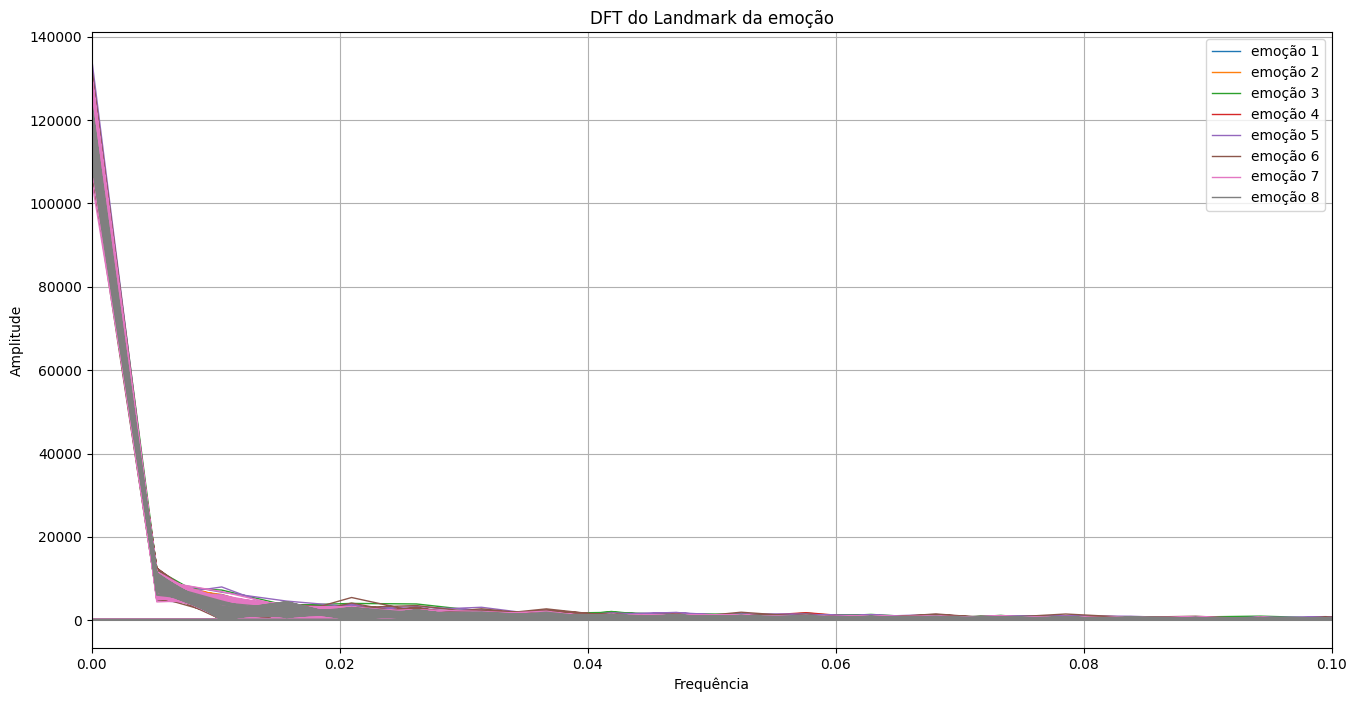

In [34]:
#Grafico do espetro de frequencias medias em DFT
lf = {}
lf1 = {}
laux1 = []
laux3 = []
b = 0

for i in range(len(emotions3d)):
    frequencias, dft_resultado = calcular_dft(data3d[i,53])

    laux1.extend(frequencias)
    laux3.extend(np.abs(dft_resultado))

    if i != 0:
        if emotions3d[i] != emotions3d[i-1]:
            if emotions3d[i-1] == 1:
                 b += 1
            if b == 2:
                 break
            lf[emotions3d[i-1]] = laux1
            lf1[emotions3d[i-1]] = laux3
            laux1 = []
            laux3 = []
            
# Criar uma única figura
plt.figure(figsize=(16, 8))

# Loop para plotar cada curva no mesmo gráfico
for i in range(8):
    plt.plot(lf[i + 1], lf1[i + 1], label=f'emoção {i + 1}',linewidth=1)

# Configurar o título e rótulos dos eixos
plt.title('DFT do Landmark da emoção')
plt.xlabel('Frequência')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0,0.1)

# Adicionar legenda para identificar cada curva
plt.legend()

# Exibir o gráfico
plt.show()

Neste gráfico do espectro de frequências médio, concluimos que a variabilidade espetral de cada emoção é pequena. Não observando nenhuma emoção com um gráfico mais distinto que outras.
Existem alguns picos de frequência não muito acentuados, sobretudo na zona curva do gráfico (0.1 a 0.4), que podem indicar emoções com níveis de intensidade diferentes.